In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

# Activation experiments

Cosine similarity of `neutral` vs. every non-empty subset of the 5 persuasion
techniques, plus `neutral` vs. `base`, per layer. Run for English and Tagalog.
Heatmap + heuristics to pick the best layer / best technique subset for
extracting a steering direction.

In [2]:
import itertools
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from safetensors import safe_open


In [3]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_DIR = PROJECT_ROOT / "data" / "activations" / "run_1"

print("Resolved RUN_DIR:", RUN_DIR)
print("Exists:", RUN_DIR.exists())

Resolved RUN_DIR: C:\Users\THINKPAD T14\OneDrive\Documents\000 THINKPAD\Projects\Collab\APART Hackathon\apart-global-south-persuasion-project\data\activations\run_1
Exists: True


In [4]:
NEUTRAL = "neutral"
NEUTRAL_TL = "neutral_tl"
BASE = "base"  # no Tagalog equivalent exists in data/activations/run_1

TECHNIQUE_SHORT = {
    "authority_endorsement_persuasion": "authority",
    "evidence_based_persuasion": "evidence",
    "expert_endorsement_persuasion": "expert",
    "logical_appeal_persuasion": "logical",
    "misrepresentation_persuasion": "misrep",
}

TECHNIQUES = list(TECHNIQUE_SHORT.keys())
TECHNIQUES_TL = [t + "_tl" for t in TECHNIQUES]
SHORT_FOR = {**TECHNIQUE_SHORT, **{t + "_tl": s for t, s in TECHNIQUE_SHORT.items()}}

### Loading + aggregation

Each `mean_assistant_token.safetensors` holds `[n_samples, n_layers, hidden]` --
one mean-over-assistant-tokens vector per example, not yet aggregated across
examples -- plus an `ids` metadata field naming each sample. Only samples whose
id contains `"everyday"` are kept (the everyday-life subset of the prompt set,
as opposed to e.g. health-sensitive categories). `aggregate_vector` pools the
filtered per-example vectors of every variant in a subset (concatenated along
the sample axis, so every example is weighted equally regardless of how many
variants are in the subset) and averages them down to a single
`[n_layers, hidden]` direction per subset.

In [5]:
ID_FILTER = "everyday"


def load_activation_samples(folder: str) -> np.ndarray:
    """[n_samples, n_layers, hidden] for one variant folder, filtered to ids containing ID_FILTER."""
    path = RUN_DIR / folder / "mean_assistant_token.safetensors"
    with safe_open(str(path), framework="pt") as f:
        tensor = f.get_tensor("activations")
        ids = json.loads(f.metadata()["ids"])
    keep = [i for i, sample_id in enumerate(ids) if ID_FILTER in sample_id]
    return tensor[keep].numpy()


def aggregate_vector(variants: list[str]) -> np.ndarray:
    """Mean activation [n_layers, hidden], pooling samples across all given variants."""
    samples = np.concatenate([load_activation_samples(v) for v in variants], axis=0)
    return samples.mean(axis=0)


def all_nonempty_subsets(items: list[str]):
    for r in range(1, len(items) + 1):
        yield from itertools.combinations(items, r)


def subset_label(subset: tuple[str, ...]) -> str:
    return "+".join(SHORT_FOR[t] for t in subset)

### Per-layer cosine similarity vs. neutral

In [6]:
def cosine_per_layer(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """a, b: [n_layers, hidden] -> [n_layers] cosine similarity."""
    a_norm = a / (np.linalg.norm(a, axis=-1, keepdims=True) + 1e-8)
    b_norm = b / (np.linalg.norm(b, axis=-1, keepdims=True) + 1e-8)
    return np.sum(a_norm * b_norm, axis=-1)


def build_subset_cosine_matrix(neutral_vec, techniques, extra_rows=None):
    """
    Cosine similarity of `neutral_vec` vs. every non-empty subset of `techniques`,
    plus any extra named comparison vectors (e.g. base).

    Returns (labels, sim_matrix [n_rows, n_layers]).
    """
    labels = []
    rows = []

    for subset in all_nonempty_subsets(techniques):
        vec = aggregate_vector(list(subset))
        labels.append(subset_label(subset))
        rows.append(cosine_per_layer(neutral_vec, vec))

    for name, vec in (extra_rows or {}).items():
        labels.append(name)
        rows.append(cosine_per_layer(neutral_vec, vec))

    return labels, np.array(rows)

### Heuristics + plotting

In [7]:
def per_layer_heuristics(sim_matrix: np.ndarray):
    """Across subsets, for each layer: avg/max/min cosine similarity to neutral."""
    return sim_matrix.mean(axis=0), sim_matrix.max(axis=0), sim_matrix.min(axis=0)


def per_subset_heuristics(labels, sim_matrix: np.ndarray) -> pd.DataFrame:
    """Across layers, for each subset: avg/max/min cosine similarity to neutral."""
    return pd.DataFrame({
        "subset": labels,
        "avg_cosine_sim": sim_matrix.mean(axis=1),
        "max_cosine_sim": sim_matrix.max(axis=1),
        "min_cosine_sim": sim_matrix.min(axis=1),
    })


def build_layer_heuristics_df(sim_matrix: np.ndarray) -> pd.DataFrame:
    avg_per_layer, max_per_layer, min_per_layer = per_layer_heuristics(sim_matrix)
    return pd.DataFrame({
        "layer": range(sim_matrix.shape[1]),
        "avg_cosine_sim": avg_per_layer,
        "max_cosine_sim": max_per_layer,
        "min_cosine_sim": min_per_layer,
    })


def plot_subset_heatmap(labels, sim_matrix, lang):
    avg_per_layer, max_per_layer, min_per_layer = per_layer_heuristics(sim_matrix)
    n_rows, n_layers = sim_matrix.shape

    fig, (ax_heat, ax_line) = plt.subplots(
        2, 1,
        figsize=(max(10, n_layers * 0.35), max(6, n_rows * 0.35) + 3),
        gridspec_kw={"height_ratios": [n_rows, 6]},
        sharex=True,
    )

    sns.heatmap(
        sim_matrix,
        ax=ax_heat,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        yticklabels=labels,
        xticklabels=[str(i) for i in range(n_layers)],
        cbar_kws={"label": "cosine similarity"},
    )
    ax_heat.set_title(f"Cosine similarity vs. neutral, per layer ({lang})")
    ax_heat.tick_params(axis="y", labelsize=7)

    ax_line.plot(range(n_layers), avg_per_layer, label="avg (all subsets)", marker="o", ms=3)
    ax_line.plot(range(n_layers), max_per_layer, label="max (all subsets)", marker="o", ms=3)
    ax_line.plot(range(n_layers), min_per_layer, label="min (all subsets)", marker="o", ms=3)
    ax_line.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax_line.set_xlabel("layer")
    ax_line.set_ylabel("cosine similarity")
    ax_line.legend(fontsize=8, loc="best")
    ax_line.grid(alpha=0.3)

    fig.tight_layout()
    return fig

In [8]:
def build_summary_table(labels, sim_matrix, combined_label, individual_labels):
    """avg/max/min cosine sim to neutral, across layers, for: all subsets combined,
    the all-techniques "combined" subset, and each individual technique."""
    overall = pd.DataFrame([{
        "subset": "all_subsets (avg over all rows)",
        "avg_cosine_sim": sim_matrix.mean(),
        "max_cosine_sim": sim_matrix.max(),
        "min_cosine_sim": sim_matrix.min(),
    }])

    full = per_subset_heuristics(labels, sim_matrix)
    order = [combined_label, *individual_labels]
    picked = full.set_index("subset").loc[order].reset_index()

    return pd.concat([overall, picked], ignore_index=True)


COMBINED_LABEL = subset_label(tuple(TECHNIQUES))  # short-name string, shared by the en and tl matrices

In [9]:
def layer_ranking_for_label(labels, sim_matrix, label):
    """Per-layer cosine sim to neutral for a single subset label, sorted ascending."""
    idx = labels.index(label)
    sims = sim_matrix[idx]
    return (
        pd.DataFrame({"layer": range(len(sims)), "cosine_sim": sims})
        .sort_values("cosine_sim")
        .reset_index(drop=True)
    )

In [10]:
SELECTED_LAYERS = [14, 0, 12, 35, 13, 24, 3]


def cosine_at_layers(labels, sim_matrix, combined_label, individual_labels, layers):
    rows = {
        label: sim_matrix[labels.index(label), layers]
        for label in [combined_label, *individual_labels]
    }
    return pd.DataFrame(rows, index=layers).T

## English

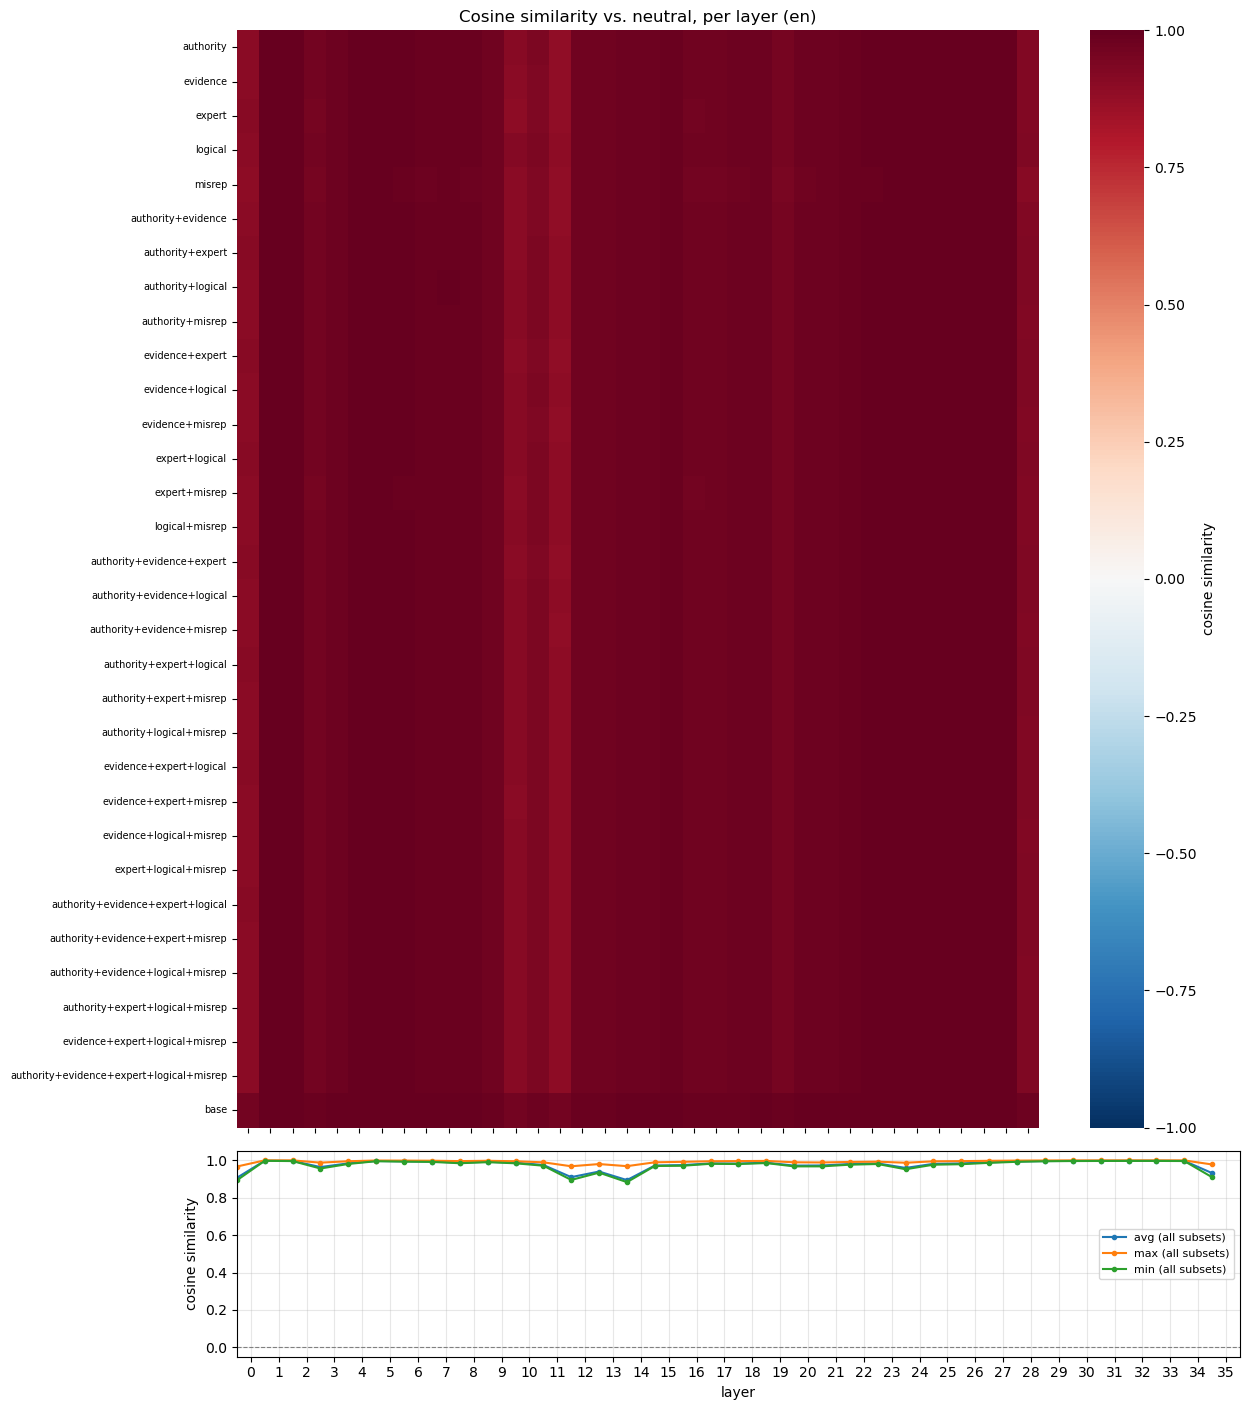

In [11]:
en_neutral_vec = aggregate_vector([NEUTRAL])
en_base_vec = aggregate_vector([BASE])

en_labels, en_sim_matrix = build_subset_cosine_matrix(
    en_neutral_vec, TECHNIQUES, extra_rows={"base": en_base_vec}
)

plot_subset_heatmap(en_labels, en_sim_matrix, "en")
plt.show()

In [12]:
en_subset_heuristics = per_subset_heuristics(en_labels, en_sim_matrix)
en_layer_heuristics = build_layer_heuristics_df(en_sim_matrix)

print("Most divergent from neutral (lowest avg cosine sim) -- candidate subsets:")
en_subset_heuristics.sort_values("avg_cosine_sim").head(10)

Most divergent from neutral (lowest avg cosine sim) -- candidate subsets:


,subset,avg_cosine_sim,max_cosine_sim,min_cosine_sim
4,misrep,0.972115,0.997022,0.882938
2,expert,0.974099,0.997302,0.889645
1,evidence,0.974396,0.997050,0.883287
13,expert+misrep,0.974537,0.997270,0.890977
0,authority,0.974676,0.997397,0.890512
11,evidence+misrep,0.974737,0.997072,0.887796
5,authority+evidence,0.974865,0.997176,0.888067
8,authority+misrep,0.974945,0.997314,0.890634
9,evidence+expert,0.975107,0.997153,0.889170
6,authority+expert,0.975178,0.997384,0.892112


In [13]:
print("Most discriminative layers (lowest avg cosine sim across all subsets):")
en_layer_heuristics.sort_values("avg_cosine_sim").head(10)

Most discriminative layers (lowest avg cosine sim across all subsets):


,layer,avg_cosine_sim,max_cosine_sim,min_cosine_sim
14,14,0.893856,0.968396,0.882938
0,0,0.905987,0.966291,0.892634
12,12,0.909645,0.967825,0.894769
35,35,0.931096,0.977351,0.909157
13,13,0.939581,0.979593,0.933722
24,24,0.958850,0.986539,0.951803
3,3,0.963528,0.987079,0.955795
20,20,0.971369,0.988990,0.967171
15,15,0.971783,0.988949,0.969265
21,21,0.972073,0.988099,0.967253


In [14]:
print("Most discriminative layers for combined (all 5 techniques):")
layer_ranking_for_label(en_labels, en_sim_matrix, COMBINED_LABEL).head(10)

Most discriminative layers for combined (all 5 techniques):


,layer,cosine_sim
0,14,0.893123
1,0,0.905103
2,12,0.909602
3,35,0.932024
4,13,0.939277
5,24,0.958967
6,3,0.963516
7,20,0.971655
8,15,0.971880
9,21,0.972358


In [15]:
print("Most discriminative layers for authority:")
layer_ranking_for_label(en_labels, en_sim_matrix, "authority").head(10)

Most discriminative layers for authority:


,layer,cosine_sim
0,14,0.890512
1,0,0.904325
2,12,0.906955
3,35,0.928054
4,13,0.938228
5,24,0.954579
6,3,0.963000
7,20,0.968808
8,21,0.969055
9,15,0.969265


In [16]:
print("Most discriminative layers for evidence:")
layer_ranking_for_label(en_labels, en_sim_matrix, "evidence").head(10)

Most discriminative layers for evidence:


,layer,cosine_sim
0,14,0.883287
1,12,0.900898
2,0,0.901365
3,35,0.929147
4,13,0.933722
5,24,0.958384
6,3,0.962365
7,15,0.969399
8,20,0.969772
9,16,0.970635


In [17]:
print("Most discriminative layers for expert:")
layer_ranking_for_label(en_labels, en_sim_matrix, "expert").head(10)

Most discriminative layers for expert:


,layer,cosine_sim
0,14,0.889645
1,12,0.894769
2,0,0.909914
3,35,0.926922
4,13,0.935820
5,24,0.956087
6,3,0.960917
7,20,0.967246
8,21,0.969190
9,15,0.969809


In [18]:
print("Most discriminative layers for logical:")
layer_ranking_for_label(en_labels, en_sim_matrix, "logical").head(10)

Most discriminative layers for logical:


,layer,cosine_sim
0,14,0.895108
1,0,0.901984
2,12,0.915672
3,35,0.931848
4,13,0.940295
5,24,0.959427
6,3,0.964732
7,15,0.971828
8,20,0.972976
9,21,0.973404


In [19]:
print("Most discriminative layers for misrep:")
layer_ranking_for_label(en_labels, en_sim_matrix, "misrep").head(10)

Most discriminative layers for misrep:


,layer,cosine_sim
0,14,0.882938
1,0,0.892634
2,12,0.903291
3,35,0.909157
4,13,0.934027
5,24,0.951803
6,3,0.955795
7,20,0.967171
8,21,0.967253
9,15,0.969718


In [20]:
cosine_at_layers(
    en_labels, en_sim_matrix, COMBINED_LABEL, [TECHNIQUE_SHORT[t] for t in TECHNIQUES], SELECTED_LAYERS
)

,14,0,12,35,13,24,3
authority+evidence+expert+logical+misrep,0.893123,0.905103,0.909602,0.932024,0.939277,0.958967,0.963516
authority,0.890512,0.904325,0.906955,0.928054,0.938228,0.954579,0.963000
evidence,0.883287,0.901365,0.900898,0.929147,0.933722,0.958384,0.962365
expert,0.889645,0.909914,0.894769,0.926922,0.935820,0.956087,0.960917
logical,0.895108,0.901984,0.915672,0.931848,0.940295,0.959427,0.964732
misrep,0.882938,0.892634,0.903291,0.909157,0.934027,0.951803,0.955795


### Summary: avg / max / min cosine sim across layers

In [21]:
build_summary_table(
    en_labels, en_sim_matrix, COMBINED_LABEL, [TECHNIQUE_SHORT[t] for t in TECHNIQUES]
)

,subset,avg_cosine_sim,max_cosine_sim,min_cosine_sim
0,all_subsets (avg over all rows),0.975921,0.999374,0.882938
1,authority+evidence+expert+logical+misrep,0.975971,0.997267,0.893123
2,authority,0.974676,0.997397,0.890512
3,evidence,0.974396,0.997050,0.883287
4,expert,0.974099,0.997302,0.889645
5,logical,0.976490,0.997202,0.895108
6,misrep,0.972115,0.997022,0.882938


## Tagalog

No `base_tl` activations exist in `data/activations/run_1`, so there is no
neutral-vs-base row for Tagalog.

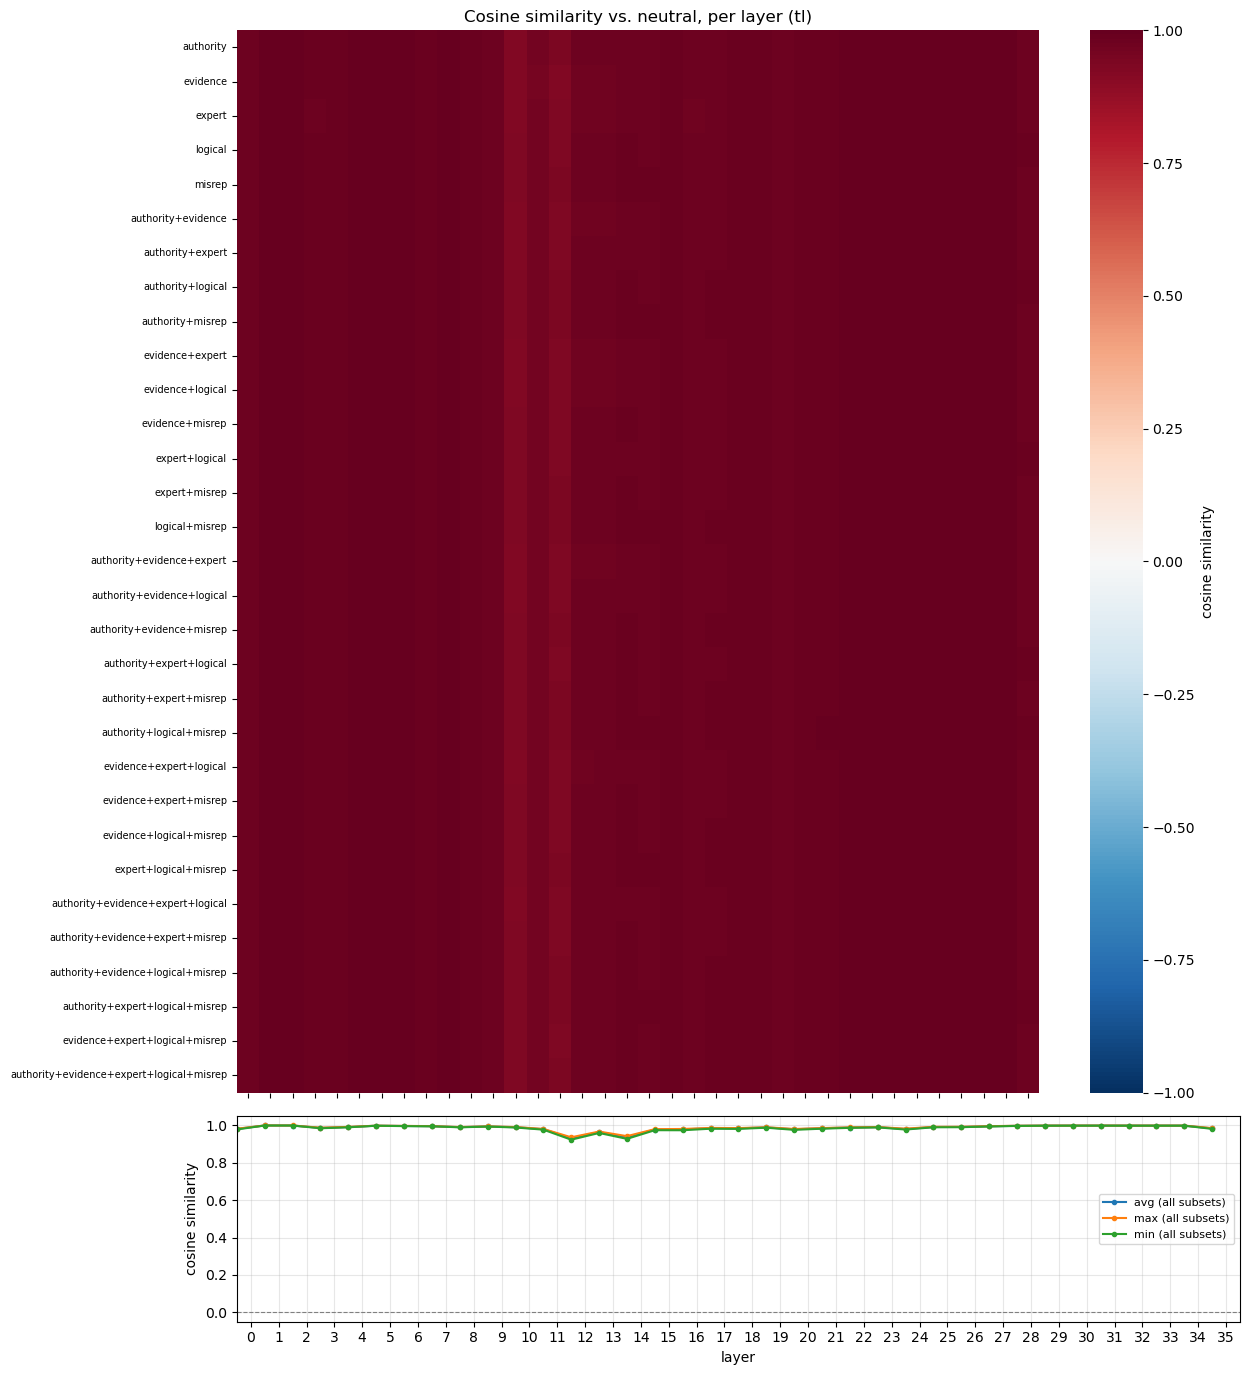

In [22]:
tl_neutral_vec = aggregate_vector([NEUTRAL_TL])

tl_labels, tl_sim_matrix = build_subset_cosine_matrix(tl_neutral_vec, TECHNIQUES_TL)

plot_subset_heatmap(tl_labels, tl_sim_matrix, "tl")
plt.show()

In [23]:
tl_subset_heuristics = per_subset_heuristics(tl_labels, tl_sim_matrix)
tl_layer_heuristics = build_layer_heuristics_df(tl_sim_matrix)

print("Most divergent from neutral (lowest avg cosine sim) -- candidate subsets:")
tl_subset_heuristics.sort_values("avg_cosine_sim").head(10)

Most divergent from neutral (lowest avg cosine sim) -- candidate subsets:


,subset,avg_cosine_sim,max_cosine_sim,min_cosine_sim
1,evidence,0.984724,0.998896,0.923026
2,expert,0.984940,0.999076,0.925723
9,evidence+expert,0.985335,0.999007,0.926010
5,authority+evidence,0.985853,0.999035,0.926876
15,authority+evidence+expert,0.985875,0.999059,0.927595
10,evidence+logical,0.985916,0.998936,0.928154
6,authority+expert,0.986050,0.999119,0.928623
21,evidence+expert+logical,0.986054,0.999003,0.928883
25,authority+evidence+expert+logical,0.986284,0.999045,0.929352
22,evidence+expert+misrep,0.986296,0.998999,0.931554


In [24]:
print("Most discriminative layers (lowest avg cosine sim across all subsets):")
tl_layer_heuristics.sort_values("avg_cosine_sim").head(10)

Most discriminative layers (lowest avg cosine sim across all subsets):


,layer,avg_cosine_sim,max_cosine_sim,min_cosine_sim
12,12,0.931031,0.935885,0.923026
14,14,0.936624,0.942055,0.927559
13,13,0.963794,0.966525,0.958963
15,15,0.977444,0.979357,0.973857
16,16,0.977974,0.980388,0.973578
20,20,0.978792,0.980256,0.975746
11,11,0.979225,0.980416,0.976707
24,24,0.979976,0.981891,0.977261
0,0,0.980655,0.981743,0.977681
35,35,0.983494,0.984896,0.980897


In [25]:
print("Most discriminative layers for combined (all 5 techniques):")
layer_ranking_for_label(tl_labels, tl_sim_matrix, COMBINED_LABEL).head(10)

Most discriminative layers for combined (all 5 techniques):


,layer,cosine_sim
0,12,0.932179
1,14,0.937617
2,13,0.964331
3,15,0.977874
4,16,0.978553
5,20,0.979369
6,11,0.979626
7,24,0.980460
8,0,0.981035
9,35,0.984026


In [26]:
print("Most discriminative layers for authority:")
layer_ranking_for_label(tl_labels, tl_sim_matrix, "authority").head(10)

Most discriminative layers for authority:


,layer,cosine_sim
0,12,0.928923
1,14,0.938274
2,13,0.963795
3,16,0.977602
4,15,0.977821
5,20,0.978665
6,11,0.979225
7,24,0.980470
8,0,0.980977
9,18,0.983169


In [27]:
print("Most discriminative layers for evidence:")
layer_ranking_for_label(tl_labels, tl_sim_matrix, "evidence").head(10)

Most discriminative layers for evidence:


,layer,cosine_sim
0,12,0.923026
1,14,0.927559
2,13,0.958963
3,16,0.973578
4,15,0.973857
5,20,0.976666
6,11,0.976707
7,24,0.977261
8,18,0.980819
9,35,0.980897


In [28]:
print("Most discriminative layers for expert:")
layer_ranking_for_label(tl_labels, tl_sim_matrix, "expert").head(10)

Most discriminative layers for expert:


,layer,cosine_sim
0,12,0.925723
1,14,0.931902
2,13,0.961438
3,16,0.974786
4,15,0.975082
5,20,0.975746
6,24,0.977368
7,11,0.977686
8,0,0.978501
9,18,0.981415


In [29]:
print("Most discriminative layers for logical:")
layer_ranking_for_label(tl_labels, tl_sim_matrix, "logical").head(10)

Most discriminative layers for logical:


,layer,cosine_sim
0,12,0.931559
1,14,0.935392
2,13,0.963640
3,15,0.977742
4,16,0.978252
5,20,0.978586
6,24,0.979406
7,11,0.979820
8,0,0.981065
9,18,0.983658


In [30]:
print("Most discriminative layers for misrep:")
layer_ranking_for_label(tl_labels, tl_sim_matrix, "misrep").head(10)

Most discriminative layers for misrep:


,layer,cosine_sim
0,12,0.935069
1,14,0.940594
2,13,0.966016
3,0,0.977681
4,15,0.978647
5,20,0.978859
6,11,0.978893
7,16,0.980168
8,24,0.980811
9,35,0.981393


In [31]:
cosine_at_layers(
    tl_labels, tl_sim_matrix, COMBINED_LABEL, [SHORT_FOR[t] for t in TECHNIQUES_TL], SELECTED_LAYERS
)

,14,0,12,35,13,24,3
authority+evidence+expert+logical+misrep,0.937617,0.981035,0.932179,0.984026,0.964331,0.980460,0.986361
authority,0.938274,0.980977,0.928923,0.983638,0.963795,0.980470,0.986008
evidence,0.927559,0.981473,0.923026,0.980897,0.958963,0.977261,0.985508
expert,0.931902,0.978501,0.925723,0.982072,0.961438,0.977368,0.984206
logical,0.935392,0.981065,0.931559,0.984437,0.963640,0.979406,0.987122
misrep,0.940594,0.977681,0.935069,0.981393,0.966016,0.980811,0.984696


### Summary: avg / max / min cosine sim across layers

In [32]:
build_summary_table(
    tl_labels, tl_sim_matrix, COMBINED_LABEL, [SHORT_FOR[t] for t in TECHNIQUES_TL]
)

,subset,avg_cosine_sim,max_cosine_sim,min_cosine_sim
0,all_subsets (avg over all rows),0.986404,0.999140,0.923026
1,authority+evidence+expert+logical+misrep,0.986709,0.999034,0.932179
2,authority,0.986413,0.999140,0.928923
3,evidence,0.984724,0.998896,0.923026
4,expert,0.984940,0.999076,0.925723
5,logical,0.986492,0.998997,0.931559
6,misrep,0.986560,0.998926,0.935069
